In [1]:
import os
from pypower import BaseMatrix, PowerSpectrumSmoothWindowMatrix, PowerSpectrumSmoothWindow, CorrelationFunctionSmoothWindow, ArrayMesh, MeshFFTPower, MeshFFTWindow, setup_logging
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from classy import Class
from qells import qell_s_spherical_vectorized, qell_k_spherical
setup_logging()
from scipy.interpolate import interp1d
from scipy.integrate import quad

# All sphere multipoles

In [3]:
ells = [0, 2]

#### Helper functions

In [4]:
def binning(ko, ki, pk):
    dk = ko[-1]-ko[-2]
    binmin, binmax = ko - dk/2., ko + dk/2.
    points = [np.linspace(kbinmin, kbinmax, 100) for (kbinmin, kbinmax) in zip(binmin, binmax)]
    ipk = interp1d(ki, pk, kind='cubic', axis=-1, bounds_error=False, fill_value=0.)
    binvol = np.array([quad(lambda k: k**2, kbinmin, kbinmax)[0] for (kbinmin, kbinmax) in zip(binmin, binmax)])
    pk_bin = np.array([np.trapz(ipk(pts) * pts**2, x=pts) for pts in points])
    return np.einsum('k,kl->lk', 1/binvol, pk_bin)

### Forward model

In [5]:
testcosmo = FlatLambdaCDM(H0=70, Om0=0.3)
zsphere = 0.8
rsphere = testcosmo.comoving_distance(zsphere).value
print(f"{rsphere:.2f}")

grid = 256
boxsize = 10000
kf = 2*np.pi/boxsize
knq = np.pi*grid/boxsize

2787.67


In [6]:
# # get the mask to compute the convolution on a mesh
# mask = np.ones((grid,)*3)
# nz = lambda z : np.heaviside(zsphere - z, 1.0)  # noqa: E731
# h = testcosmo.h
# coord = get_cartesian_coord(gridsize=grid, MPCboxsize=boxsize) # coordinates in Mpc/h
# redshifts = get_redshift(coord * h, testcosmo)
# norm, mask = apply_selection(field=mask, redshifts=redshifts, nz=nz, vector_input=True, verbose=False, return_norm=True, mask=None)
# geomesh = ArrayMesh(array=mask, boxsize=boxsize, nmesh=grid)

# get the full field for reference
# power_ref = MeshFFTPower(mesh1=geomesh, edges=np.linspace(kf, knq, grid//2, endpoint=False), ells=(0, 2, 4), los='z').poles

In [7]:
# power_ref = MeshFFTPower.load("data/poles_RSD_False__box_10000_grid_256_zsphere_0-8_seed_8263.npy").poles
# winmesh = MeshFFTWindow(mesh1=geomesh, power_ref=power_ref, edgesin=np.linspace(kf, knq, 128))
# winmesh.save("data/meshfftwindow.npy")
# computation takes about 25 minutes ; result is saved in data/meshfftwindow.npy and will be loaded later in the notebook

In [8]:
# datapath = os.path.join(os.getcwd(), "data", "sphere_multiple_z_08") #_z_08_RSD")
# realpaths = os.listdir(datapath)
# with open(os.path.join(datapath, realpaths[0]), 'rb') as f:   
#     mean_obs = np.zeros_like(np.load(f))
#     std_obs = np.zeros_like(mean_obs)

# for real in realpaths:
#     with open(os.path.join(datapath, real), "rb") as f:
#         pk = np.load(f)
#         mean_obs += pk
#         std_obs += np.abs(pk)**2
# del pk
# mean_obs /= len(realpaths)

# std_obs /= len(realpaths)
# std_obs -= mean_obs**2 
# std_obs = np.sqrt(std_obs)
# std_obs = std_obs[0:-1]
# std_obs /= np.sqrt(len(realpaths) -1) # unbiased estimator ; and take the mean of the stds

# k_mean = mean_obs[-1]
# Pkl_mean = mean_obs[0:-1]

# print(f"Zsphere used : {zsphere}.\nCheck that it is the same as in the data path {datapath}")

This below agrees with Domitille above

In [9]:
datapath = os.path.join(os.getcwd(), "data", "sphere_multiple_z_08_RSD") #_z_08_RSD")
realpaths = os.listdir(datapath)

pks = []
for real in realpaths:
    with open(os.path.join(datapath, real), "rb") as f:
        data = np.load(f)
        kmask = (0.005<data[-1]) # let's be realistic 
        p0, p2, p4, k = data[:,kmask]
        pks.append([p0, p2, p4]) 
pks = np.array(pks)
k = k.astype(np.longdouble) 

print (k.shape, pks.shape)

pk_fm, pk_std = np.mean(pks, axis=0), np.std(pks, axis=0)
pk_std /= pks.shape[0]**.5 # we divide the variance by the number of realisations so that we have the variance of the mean

(119,) (100, 3, 119)


### Theory

In [10]:
M = Class()
M.set({'output':'mPk', # we want the power spectrum
            'omega_b':0.0223,'omega_cdm':0.112,'h':0.6736,'A_s':2.097e-9,'n_s':0.9652,'tau_reio':0.055, 
           'z_max_pk':100.0, 
           # 'P_k_max_h/Mpc': 1.0, 
           'P_k_max_1/Mpc': 1.0, 
           'non linear':'halofit'
      })
M.compute()

kk = np.linspace(1e-4, 0.2, 512) # , dtype=np.longdouble) # k values # np.geomspace(1e-4, 0.2, 500, dtype=np.longdouble) # 
dk = kk[-1]-kk[-2]
kedges = np.concatenate((kk-dk/2., [kk[-1]+dk/2.]))
pk_lin = np.array([M.pk(ki, 0.) for ki in kk]) # linear power spectrum today ?(z = 0) at each k
pk_lin_ = interp1d(kk, pk_lin, kind='cubic')(k)

Kaiser

In [11]:
mu = {
    0: {0: 1., 2: 0., 4: 0.},
    2: {0: 1. / 3., 2: 2. / 3., 4: 0.},
    4: {0: 1. / 5., 2: 4. / 7., 4: 8. / 35.},
}

In [12]:
b1, f1 = 1., M.scale_independent_growth_factor_f(0.)

In [13]:
beta_l = np.array([b1**2 * mu[0][l] + 2*b1*f1*mu[2][l] + f1**2*mu[4][l] for l in ells])
pk = np.einsum('l,k->lk', beta_l, pk_lin)

Theory, but in real space (monopole only): not useful to compare in redshift space

In [14]:
def W00(k_, R=1.): # I do a totally symmetric window in k and p
    k = k_ * R
    p = k + 1e-2 # trick to not get peaks
    k, p = k[..., np.newaxis], p[np.newaxis, ...]
    return 2*R**3 * (1/np.pi)*(2*(-((1/(32*k*(k - p)**4 * p*(k + p)**4))*(p*(-5*k**6 + p**4*(-6 + 5*p**2) - 3*k**2*p**2*(4 + 5*p**2) + 3*k**4*(6 + 5*p**2))*np.cos(p) * np.sin(k) + k*np.cos(k)*(6*p*(3*k**4 + k**2*(4 - 6*p**2) + p**2*(4 + 3*p**2)) * np.cos(p) + (5*k**6 + 18*p**4 - 5*p**6 + 3*k**2*p**2*(-4 + 5*p**2) - 3*k**4*(2 + 5*p**2)) * np.sin(p)) + 3*(-8*k*p*(k**4 + p**2 + p**4 + k**2*(1 - 2*p**2)) + (3*k**6 + k**4*(2 - 3*p**2) - 3*k**2*p**2*(-4 + p**2) + p**4*(2 + 3*p**2))*np.sin(k)*np.sin(p)))) + (1/(32*k*(k - p)**4*p*(k + p)**4))*(24*k*p*(k**2 + p**2) * np.cos(p)**2*np.sin(k)**2 + (k**2 - p**2)*np.cos(p) * np.sin(k)*(-5*k**4*p + 6*p**3 - 5*p**5 + 2*k**2*p*(9 + 5*p**2) - 24*k*(k**2 + 3*p**2)*np.sin(k)*np.sin(p)) + np.cos(k)*(6*k*p*(3*k**4 + k**2*(4 - 6*p**2) + p**2*(4 + 3*p**2)) * np.cos(p) + 24*p*(-3*k**4 + 2*k**2*p**2 + p**4)*np.cos(p)**2*np.sin(k) + (k**2 - p**2) * np.sin(p)*(5*k**5 + k*p**2*(-18 + 5*p**2) - 2*k**3*(3 + 5*p**2) + 24*p*(3*k**2 + p**2)*np.sin(k)*np.sin(p))) + 12*k*np.cos(k)**2*(-2*p*(k**2 + p**2) * np.cos(2*p) + (k**4 + 2*k**2*p**2 - 3*p**4)*np.sin(2*p)) + 3*((3*k**6 + k**4*(2 - 3*p**2) - 3*k**2*p**2*(-4 + p**2) + p**4*(2 + 3*p**2))*np.sin(k)*np.sin(p) - 8*k*p*(k**2 + p**2)*np.sin(k)**2*np.sin(p)**2 - 2*(k**4 + 6*k**2*p**2 + p**4)*np.sin(2*k)*np.sin(2*p)))))

In [15]:
w00_a = W00(kk, R=rsphere)
qk = qell_k_spherical(0, rsphere * kk)
w00_a -= np.einsum('k,p->kp', qk/qk[0], w00_a[0]) # integral constraint
wpk_a = np.einsum("p, kp, p -> kp", kk**2, w00_a, pk[0]) # theory only for monopole
pk_a = np.trapz(wpk_a, kk, axis = -1)
pk_a = binning(k, kk, [pk_a])[0]

### Arnaud

$Q_\ell(k)$ (for ICs)

In [16]:
# qk = np.array([qell_k_spherical(ell, rsphere * kk).tolist() for ell in ells], dtype=np.float32)
qk = np.load("data/qk.npy")  # careful this only works for the original kk values, if changed then recompute qk

In [17]:
# qknor = np.array([qell_k_spherical(ell, kk).tolist() for ell in ells], dtype=np.float32) # without the rsphere factor to chack against what was done before

In [18]:
testk = np.geomspace(0.2, 42, 100)
testqk2 = qell_k_spherical(2, testk).astype(np.float32)

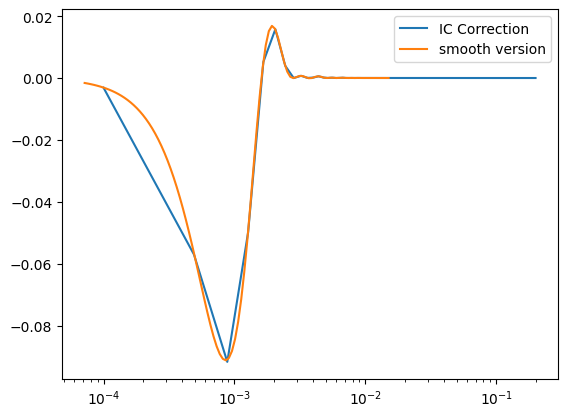

In [19]:
plt.plot(kk, qk[1]/qk[0, 0], label="IC Correction")
plt.plot(testk/rsphere, testqk2/qell_k_spherical(0, testk[0]), label="smooth version")
# plt.plot(kk, qknor[1]/qknor[0, 0], label = "old IC correction", marker = 'x') # ça écrase tout
plt.legend()
plt.xscale("log")

$Q_\ell(s)$

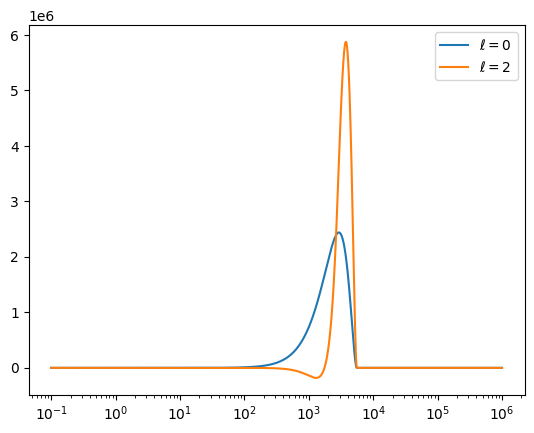

In [20]:
ss = np.geomspace(1e-4, 1e6, 1024 * 16) # configuration space separation for FFTlog
ss = ss[ss > 0.1]
qs = [qell_s_spherical_vectorized(ell, ss, rsphere) for ell in ells] 
for i, ell in enumerate(ells): plt.plot(ss, ss**2 * qs[i], label=r'$\ell=%s$' % ell)
plt.xscale('log')
plt.legend()

`class pypower.smooth_window.PowerSpectrumSmoothWindow(edges, modes, power_nonorm, nmodes, projs, wnorm_ref=None, **kwargs)`

In [21]:
%%time
window = CorrelationFunctionSmoothWindow(ss, qs, projs=[(ell, 0) for ell in ells])
wmatrix = PowerSpectrumSmoothWindowMatrix(kk, projsin=ells, projsout=ells, window=window, sep=ss, 
                                          kin_rebin=1, kin_lim=(0, 2e1), default_zero=True)
# factorout = 3
# wmatrix.slice_x(sliceout=slice(0, len(wmatrix.xout[0]) // factorout * factorout, factorout))  # rebin observed ks to dk = 0.0O5
# wmatrix.select_x(xinlim=(0., 0.2), xoutlim=(0., 0.2))  # apply k-cut to both input and output; some margin for inp

[000012.82]  08-01 01:11  CorrelationFunctionSmoothWindow INFO     No window provided for projection Projection(ell=4, wa_order=0), defaulting to 0.
CPU times: user 22.8 s, sys: 1.1 s, total: 23.9 s
Wall time: 25.8 s


In [22]:
# wlm_arnaud = np.array(wmatrix.unpacked())
# pp = wmatrix.xin[0]
# pk__ = interp1d(kk, pk, kind='cubic', axis=-1, bounds_error=False, fill_value=0.)(pp)
# wpk_arnaud = np.einsum("p,lmpk,mp->lkp", pp**-1, wlm_arnaud, pk__) 
# pk_arnaud = np.trapz(wpk_arnaud, pp, axis = -1) 
# pk_arnaud = binning(k, kk, pk_arnaud)

In [23]:
pk__ = interp1d(kk, pk, kind='cubic', axis=-1, bounds_error=False, fill_value=0.)(wmatrix.xin[0])
pk_arnaud = wmatrix.dot([pk__]).reshape(len(ells),-1)
# print (pk.shape, pk__.shape, k.shape, kk.shape, pk_arnaud.shape)
pk_arnaud = binning(k, kk, pk_arnaud)

### Pierre

In [24]:
from sympy.physics.wigner import wigner_3j
from scipy.special import spherical_jn
from lib.fftlog import FFTLog, MPC

# from mpmath import gamma # switch to mpmath instead of numpy for increased floating point precision
from scipy.special import gamma, loggamma
def MPC(l, pn):
    """ matrix for spherical bessel transform from power spectrum to correlation function """
    # return np.pi**-1.5 * 2.**(-2. * pn) * gamma(1.5 + l / 2. - pn) / gamma(l / 2. + pn)
    return np.pi**-1.5 * 2.**(-2. * pn) * np.exp(loggamma(1.5 + l / 2. - pn) - loggamma(l / 2. + pn))

In [25]:
%%time
fftsettings = dict(Nmax=1024 * 4, xmin=1., xmax=1.e5, bias=-1.6, window=0.2) # PZ: I put a somewhat low sampling but it seems ok
fft = FFTLog(**fftsettings)
pPow = np.exp(np.einsum('n,s->ns', -fft.Pow-3., np.log(kk)))
Mat = 4 * np.pi * np.array([[MPC(ell, p) for p in -0.5*fft.Pow] for ell in ells]) # , dtype = 'clongdouble')
ClmL = np.array([[[(2*l+1) * float(wigner_3j(l, m, L, 0, 0, 0)**2) for L in ells] for m in ells] for l in ells])
qlm = np.einsum('lmL,Ls->lms', ClmL, qs)
ks = kk[..., np.newaxis] * ss[np.newaxis, ...]
jlks = np.array([spherical_jn(ell, ks) for ell in ells])
qj = np.einsum('lms,lks->lmks', qlm, jlks)
coef = fft.Coef(ss, qj, extrap = 'padding') # PZ: vectorized, finally
wlm_pierre = np.einsum('lmkn,np,mn->lmkp', coef, pPow, Mat)
signs = np.array([[(-1j)**l * 1j**m for m in ells] for l in ells])
wlm_pierre = np.einsum('lm,lmkp->lmkp', signs, wlm_pierre)
# wlm_pierre = np.real(wlm_pierre) # here we do only even multipoles

CPU times: user 21.8 s, sys: 1.18 s, total: 23 s
Wall time: 25.1 s


In [26]:
# from matplotlib.colors import SymLogNorm
# plt.figure(figsize=(5, 5))
# ax = plt.imshow(np.real(wlm_pierre[0,0]), norm=SymLogNorm(linthresh=0.01, linscale=0.01, vmin=1e2))
# cbar = plt.colorbar(ax, shrink=0.7)
# plt.show()

In [27]:
wpk_pierre = np.einsum("p,lmpk,mp->lkp", kk**2, wlm_pierre, pk)
pk_pierre = np.trapz(wpk_pierre, kk, axis = -1)
pk_pierre = binning(k, kk, pk_pierre)

In [28]:
wlm_diag = 1. * wlm_pierre; wlm_diag[0,1] *= 0.; wlm_diag[1,0] *= 0.

wpk_diag = np.einsum("p,lmpk,mp->lkp", kk**2, wlm_diag, pk)
pk_diag = np.trapz(wpk_diag, kk, axis = -1)
pk_diag = binning(k, kk, pk_diag)

In [29]:
# wlm_pierre_ic = wlm_pierre - np.einsum('lk,mp->lmkp', qk / qk[0, 0], wlm_pierre[0,:,0,:]) # integral constraint
# wpk_pierre_ic = np.einsum("p,lmpk,mp->lkp", kk**2, wlm_pierre_ic, pk)
# pk_pierre_ic = np.trapz(wpk_pierre_ic, kk, axis = -1)
# pk_pierre_ic = binning(k, kk, pk_pierre_ic)

In [30]:
def getW(s, QLs, k_array, p_array, Nl=5): # oldschool, not used
    Qlm = np.einsum('lLm,Ls->lms', ClLm[:Nl,:Nl,:Nl], QLs[:Nl])
    fftsettings = dict(Nmax=2048, xmin=1.e-2, xmax=1.e6, bias=-1.6)     
    fft = FFTLog(**fftsettings)
    pPow = np.exp(np.einsum('n,s->ns', -fft.Pow-3., np.log(p_array)))
    M = np.empty(shape=(Nl, fft.Pow.shape[0]), dtype='complex')
    for l in range(Nl): 
        M[l] = 4 * np.pi * MPC(l, -0.5*fft.Pow) # the factors of pi are correct
    Coef = np.empty(shape=(Nl, Nl, len(k_array), fft.Pow.shape[0]), dtype='complex')
    for l in range(Nl):
        for m in range(Nl):
            for i, k in enumerate(k_array):
                Coef[l,m,i] = (-1j)**l * 1j**m * fft.Coef(s, Qlm[l,m]*spherical_jn(l, k*s), extrap = 'padding')
    Wlm = np.einsum('lmkn,np,mn->lmkp', Coef, pPow, M) 
    return Wlm

### Comparison

/Users/pierre/.pyenv/versions/3.11.9/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pierre/.pyenv/versions/3.11.9/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


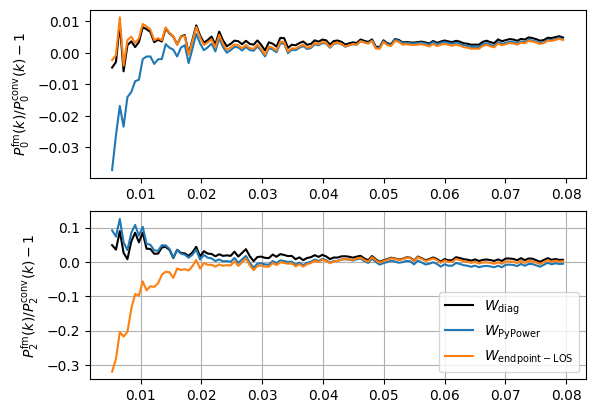

In [31]:
f, ax = plt.subplots(len(ells),1)
for pk_c, l, c in zip([pk_diag, pk_arnaud, pk_pierre], ['diag', 'PyPower', 'endpoint-LOS'], ['k', 'C0', 'C1']): 
    for i, ell in enumerate(ells):     
        ax[i].plot(k, pk_fm[i]/pk_c[i]-1, c, label=r'$W_{\rm %s}$' % l)
        ax[i].set_ylabel(r'$P_%s^{\rm fm}(k) / P_%s^{\rm conv}(k)-1$' % (ell, ell))
# plt.fill_between(k, -pk_std/pk_lin_, pk_std/pk_lin_, color='grey', alpha=.5)

# plt.ylim(-0.01, 0.01)
plt.grid()
plt.legend()
plt.show()

NameError: name 'pk_pierre_ic' is not defined

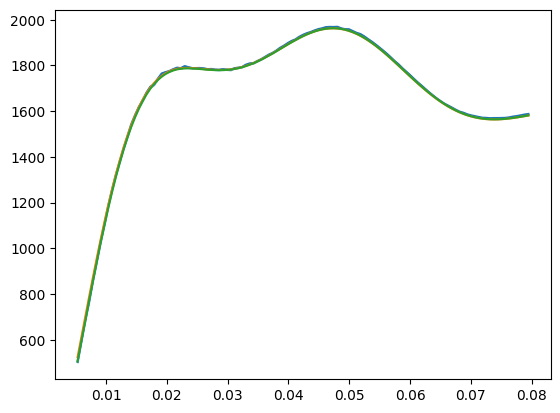

In [32]:
#plt.plot(k, k * pk_lin_, 'k--')
# plt.plot(k, k* pk_a, 'k')
for i, ell in enumerate(ells): 
    plt.plot(k, k* pk_fm[i], 'C0', label = 'FM' if i == 0 else None)
    plt.fill_between(k, k* (pk_fm[i] - pk_std[i]), k* (pk_fm[i] + pk_std[i]), color='C0', alpha=0.5)
    plt.plot(k, k* pk_arnaud[i], 'C1', label = 'Arnaud' if i == 0 else None)
    plt.plot(k, k* pk_pierre[i], 'C2', label = 'Pierre' if i == 0 else None)
    plt.plot(k, k* pk_pierre_ic[i], 'C3--', label = 'Pierre IC' if i == 0 else None)
plt.legend()